# Camber surface vectors
The purpose of this notebook is to calculate the normal, streamwise and spanwise vectors on the blade camber surface. These information are needed from the body force model

### import

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../../')
import Grid

### compute the meridional grid object
instantiate blade and block object in order to generate the bladed domain grid, properly trimmed

In [4]:
# compute the bladed domain block object
data_folder_path = '../../Grid/geo/'
units = '[m]'
nstream = 45
nspan = 20
hub = Grid.src.Curve(curve_filepath=data_folder_path + 'iris_hub.curve', units='m', degree_spline=3)
shroud = Grid.src.Curve(curve_filepath=data_folder_path + 'iris_shroud.curve', units='m', degree_spline=3)
bladed_block = Grid.src.Block(hub, shroud, blade_file=data_folder_path + 'iris_blade.curve', block_type='blade',
                     nstream=nstream, nspan=nspan)

# compute the blade object info, in order to cut the block appropriately
blade = Grid.src.Blade(data_folder_path + 'iris_blade.curve')
blade.find_inlet_points()
blade.find_outlet_points()

# cut the bladed block properly, and compute the meridional structured mesh
bladed_block.add_inlet_outlet_curves(blade.inlet, blade.outlet)
bladed_block.extend_inlet_outlet_curves()
bladed_block.find_intersections()
bladed_block.bladed_zone_trim()
bladed_block.spline_of_trim()
bladed_block.sample(sampling_mode='clustering')
bladed_block.compute_span_points(sampling_mode='clustering')
bladed_block.compute_double_grid()

### blade camber surface
using the information of the bladed block, find the camber surface, defined only on the $(z,r)$ grid of the structured mesh. 

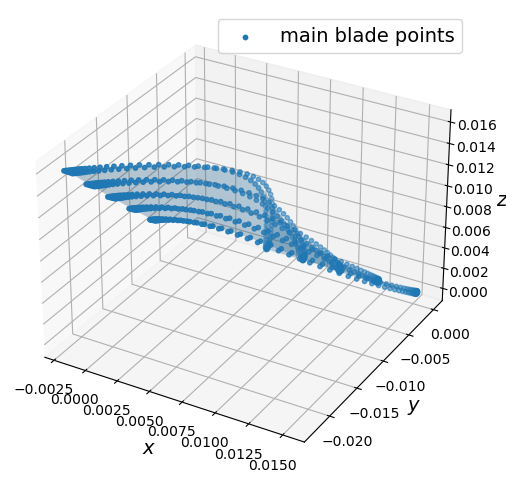

In [7]:
blade.find_camber_surface(bladed_block)
blade.plot_camber_surface()

### blade surface vectors
find the normal, streamwise and spanwise vectore on the camber surface. The streamline vector $\mathbf{t}_1$ is the normalized vector connecting two subsequent streamwise locations on the blade surface, while the spanline vector $\mathbf{t}_2$ connects two subsequent spanwise locations. The normal vector $\mathbf{n}$ is obtained with the cross product of the previous 2 vectors: $\mathbf{n} = \mathbf{t}_1 \times \mathbf{t}_2$

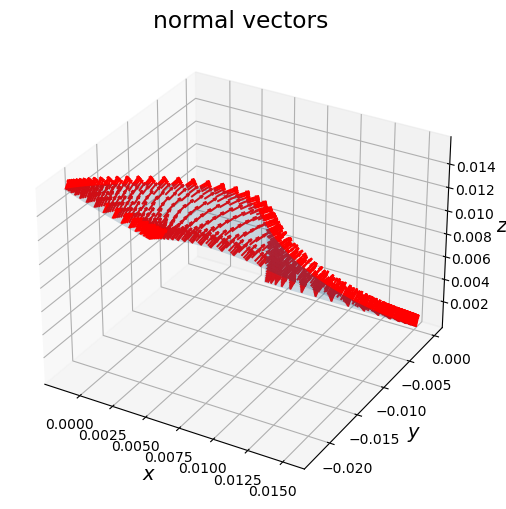

In [8]:
blade.compute_camber_vectors()
blade.show_normal_vectors()

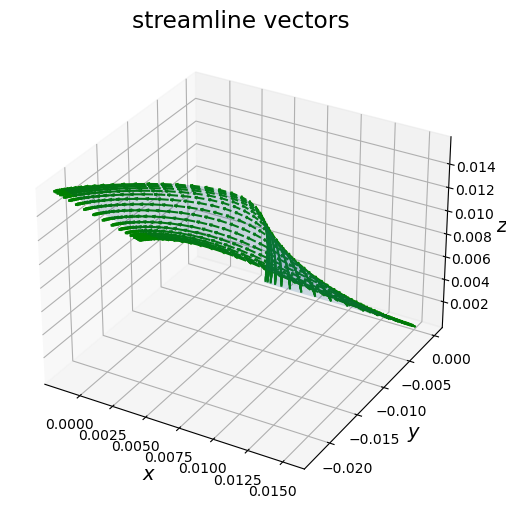

In [10]:
blade.show_streamline_vectors()

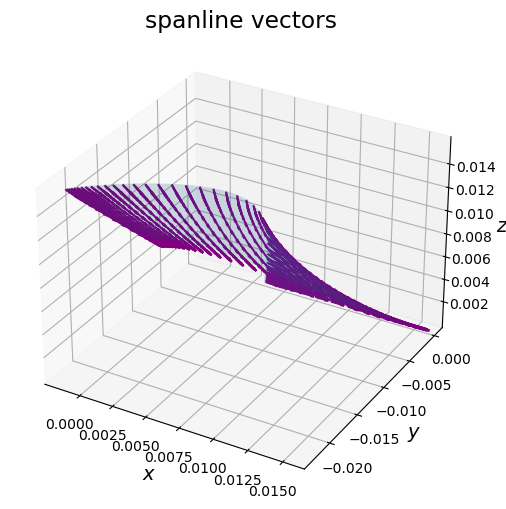

In [11]:
blade.show_spanline_vectors()